# EV Charging Session Clustering

**Objective:** Group charging sessions by energy, duration, arrival time, charger power, state of charge, and dwell time.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["energy_kwh", "duration_minutes", "arrival_hour", "charger_kw", "start_soc_pct", "dwell_minutes"]
PROFILE_CENTERS = {
  "commuter_topup": [
    16,
    48,
    9,
    22,
    55,
    70
  ],
  "overnight_home": [
    38,
    390,
    21,
    7,
    28,
    480
  ],
  "rapid_transit": [
    44,
    42,
    15,
    120,
    18,
    50
  ],
  "workplace": [
    25,
    210,
    10,
    11,
    45,
    420
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,energy_kwh,duration_minutes,arrival_hour,charger_kw,start_soc_pct,dwell_minutes,generator_profile
0,56.376,34.821,13.892,112.606,16.469,44.612,rapid_transit
1,14.953,50.054,8.830,22.723,56.991,79.245,commuter_topup
2,46.166,39.394,12.627,111.065,17.902,55.828,rapid_transit
3,38.023,407.485,23.447,8.153,28.867,508.298,overnight_home
4,16.754,45.439,8.630,24.998,49.277,53.111,commuter_topup


,count,mean,std,min,25%,50%,75%,max
energy_kwh,492.0,30.725,11.178,11.257,20.431,30.177,41.020,56.376
duration_minutes,492.0,170.980,144.945,29.200,44.048,57.293,252.684,480.084
arrival_hour,500.0,13.663,4.906,6.947,9.408,12.112,17.462,26.161
charger_kw,500.0,39.923,46.693,4.931,8.589,15.128,42.092,140.668
start_soc_pct,500.0,36.467,14.914,13.655,22.247,33.956,49.671,68.846
dwell_minutes,500.0,256.077,200.591,35.414,58.017,202.868,453.089,578.894


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=4 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.6582,0.4469
1,3,0.7001,0.4344
2,4,0.7399,0.3549
3,5,0.6104,0.7100
4,6,0.6007,0.9213


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.7399,0.3549
1,Agglomerative,0.7386,0.3598


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.9894


,records,energy_kwh,duration_minutes,arrival_hour,charger_kw,start_soc_pct,dwell_minutes
cluster,,,,,,,
0,125,15.866,47.666,9.031,21.998,54.745,69.230
1,125,43.122,41.707,14.855,119.553,17.830,49.313
2,123,38.251,390.664,20.839,7.041,28.089,481.379
3,127,25.287,209.399,10.101,11.035,44.936,425.286


cluster,0,1,2,3,All
generator_profile,,,,,
commuter_topup,125,0,0,0,125
overnight_home,0,0,123,2,125
rapid_transit,0,125,0,0,125
workplace,0,0,0,125,125
All,125,125,123,127,500


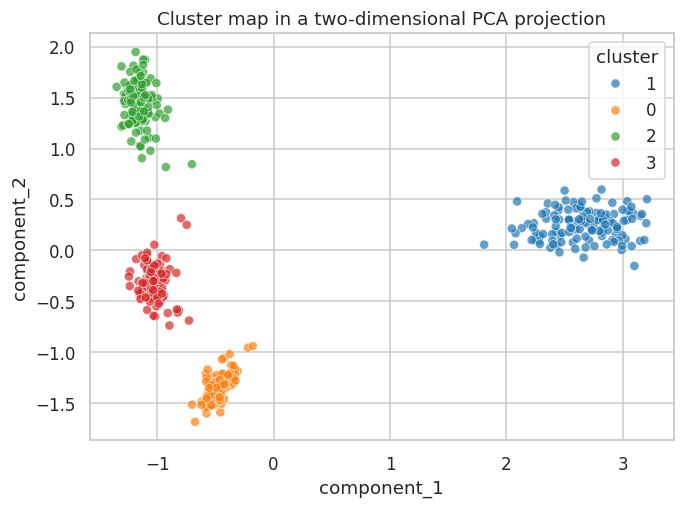

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,energy_kwh,duration_minutes,arrival_hour,charger_kw,start_soc_pct,dwell_minutes,predicted_cluster
0,30.177,57.293,12.112,15.128,33.956,202.868,3


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
